## Setup

In [16]:
import os
os.environ["R_HOME"] = "/Library/Frameworks/R.framework/Resources"

In [17]:
%load_ext rpy2.ipython
%load_ext autoreload
%autoreload 2

%matplotlib inline  
from matplotlib import rcParams
rcParams['figure.figsize'] = (16, 100)

import warnings
from rpy2.rinterface import RRuntimeWarning
warnings.filterwarnings("ignore") # Ignore all warnings
# warnings.filterwarnings("ignore", category=RRuntimeWarning) # Show some warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
%%javascript
// Disable auto-scrolling
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false;
}

<IPython.core.display.Javascript object>

## TidyCensus Example

This notebook grabs data from the US Census using the [tidycensus package in R](https://walker-data.com/tidycensus/index.html). Make sure you have installed the `tidyverse` and `tidycensus` packages.

In [19]:
%%R

install.packages("tidycensus")
install.packages("tidyverse")


The downloaded binary packages are in
	/var/folders/j5/twx6v7jj4nq17ymrbt5c1klw0000gn/T//RtmprGLtLu/downloaded_packages

The downloaded binary packages are in
	/var/folders/j5/twx6v7jj4nq17ymrbt5c1klw0000gn/T//RtmprGLtLu/downloaded_packages


trying URL 'https://cloud.r-project.org/bin/macosx/big-sur-arm64/contrib/4.5/tidycensus_1.7.5.tgz'
Content type 'application/x-gzip' length 3512637 bytes (3.3 MB)
downloaded 3.3 MB

trying URL 'https://cloud.r-project.org/bin/macosx/big-sur-arm64/contrib/4.5/tidyverse_2.0.0.tgz'
Content type 'application/x-gzip' length 428840 bytes (418 KB)
downloaded 418 KB



In [20]:
%%R 

library(tidycensus)
library(tidyverse)

# store any shapefiles we grab from the census in ~/Library/Caches/tigris
# in case the government removes the shapefiles FTP server again 😭
options(tigris_use_cache = TRUE)

### Step 1 \| Get a Census API key

Get a Census API key [here](https://api.census.gov/data/key_signup.html).

Then make a new file called `.env` in this folder and put it in there. 

The `.env` file should look like this:

```bash
CENSUS_API_KEY="your-api-key-here"
```

This is what is known as an environment variable. We load it below in Python

In [21]:
from dotenv import load_dotenv
load_dotenv() # <- searches for a file named .env and loads the environment variables in it

True

In [22]:
%%R
census_api_key(Sys.getenv("CENSUS_API_KEY"))

To install your API key for use in future sessions, run this function with `install = TRUE`.


### Step 2 \| Figure out what tables you want data from and at what geographic granularity

Use <https://censusreporter.org/> to figure out which tables you want.

We want to see which demographic factors are associated with obesity rates at the census tract level in New York State. Based on public-health literature, we pull:

- **Race / ethnicity** (table `B03002`): White, Black, Asian, Hispanic
- **Sex** (table `B01001`): Male, Female
- **Poverty** (table `B17001`): people below the poverty line
- **Median household income** (table `B19013`) as a secondary SES control
- **Total population** (table `B01003`) as the denominator

We pull at the census tract level for all of New York State so we can join to `ny_obesity_merged.csv` on `GEOID` / `TractFIPS`.

In [23]:
%%R 

# Pull ACS 5-year variables that might explain obesity rates.
# All tracts in NY state so we can join to ny_obesity_merged.csv.

ny_census_data <- get_acs(
  geography = "tract",
  state = "NY",
  variables = c(
    # total population (denominator for race / sex shares)
    population      = "B01003_001",
    # sex: male + female (total is B01001_001)
    male            = "B01001_002",
    female          = "B01001_026",
    # race / ethnicity (table B03002, "not Hispanic" + Hispanic)
    race_total      = "B03002_001",
    white_nh        = "B03002_003",
    black_nh        = "B03002_004",
    asian_nh        = "B03002_006",
    hispanic        = "B03002_012",
    # poverty (table B17001)
    pov_total       = "B17001_001",
    pov_below       = "B17001_002",
    # median household income
    med_inc         = "B19013_001"
  ),
  year = 2021,
  survey = "acs5",
  geometry = TRUE
)

ny_census_data


Simple feature collection with 59521 features and 5 fields (with 143 geometries empty)
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -79.76215 ymin: 40.4961 xmax: -71.85621 ymax: 45.01585
Geodetic CRS:  NAD83
First 10 features:
         GEOID                                      NAME   variable estimate
1  36081014700 Census Tract 147, Queens County, New York       male     1362
2  36081014700 Census Tract 147, Queens County, New York     female     1501
3  36081014700 Census Tract 147, Queens County, New York population     2863
4  36081014700 Census Tract 147, Queens County, New York race_total     2863
5  36081014700 Census Tract 147, Queens County, New York   white_nh     1784
6  36081014700 Census Tract 147, Queens County, New York   black_nh      156
7  36081014700 Census Tract 147, Queens County, New York   asian_nh      340
8  36081014700 Census Tract 147, Queens County, New York   hispanic      462
9  36081014700 Census Tract 147, Queens County, New York  

Getting data from the 2017-2021 5-year ACS
Using FIPS code '36' for state 'NY'


### Step 3 | Pivot to Wide Format

Pivot from long to wide using `pivot_wider`.

Depending on what you're trying to do, you may want the data in long or wide format. This example pivots the data to wide format, which will help us with mapping later on in the notebook.

In [24]:
%%R 

ny_census_data <- ny_census_data %>% 
  pivot_wider(
    names_from = variable, 
    values_from = c(estimate, moe),
    names_glue = "{variable}_{.value}"
  )

ny_census_data


Simple feature collection with 5411 features and 24 fields (with 13 geometries empty)
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -79.76215 ymin: 40.4961 xmax: -71.85621 ymax: 45.01585
Geodetic CRS:  NAD83
# A tibble: 5,411 × 25
   GEOID       NAME                       geometry male_estimate female_estimate
   <chr>       <chr>            <MULTIPOLYGON [°]>         <dbl>           <dbl>
 1 36081014700 Census T… (((-73.9137 40.76548, -7…          1362            1501
 2 36047058400 Census T… (((-73.96103 40.59616, -…          1494            2161
 3 36061006900 Census T… (((-74.02064 40.73039, -…          1277            1173
 4 36047073000 Census T… (((-73.93345 40.6257, -7…          1185            1491
 5 36047100400 Census T… (((-73.90735 40.63083, -…          1189            1815
 6 36047055700 Census T… (((-73.96279 40.72256, -…           975             859
 7 36103135102 Census T… (((-73.28083 40.85016, -…          2432            2321
 8 36005022101 Cens

### Step 4 | Do calculations with `mutate`

Convert raw counts into the proportions we'll actually use in the regression (shares of the population that are female, white, Black, Asian, Hispanic, and below the poverty line).

In [25]:
%%R 

ny_census_data <- ny_census_data %>% 
    mutate(
        county = str_split(NAME, ",") %>% map_chr(2) %>% str_trim(),
        pct_female   = female_estimate   / population_estimate,
        pct_white    = white_nh_estimate / race_total_estimate,
        pct_black    = black_nh_estimate / race_total_estimate,
        pct_asian    = asian_nh_estimate / race_total_estimate,
        pct_hispanic = hispanic_estimate / race_total_estimate,
        pct_poverty  = pov_below_estimate / pov_total_estimate
    ) 

ny_census_data


Simple feature collection with 5411 features and 31 fields (with 13 geometries empty)
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -79.76215 ymin: 40.4961 xmax: -71.85621 ymax: 45.01585
Geodetic CRS:  NAD83
# A tibble: 5,411 × 32
   GEOID       NAME                       geometry male_estimate female_estimate
 * <chr>       <chr>            <MULTIPOLYGON [°]>         <dbl>           <dbl>
 1 36081014700 Census T… (((-73.9137 40.76548, -7…          1362            1501
 2 36047058400 Census T… (((-73.96103 40.59616, -…          1494            2161
 3 36061006900 Census T… (((-74.02064 40.73039, -…          1277            1173
 4 36047073000 Census T… (((-73.93345 40.6257, -7…          1185            1491
 5 36047100400 Census T… (((-73.90735 40.63083, -…          1189            1815
 6 36047055700 Census T… (((-73.96279 40.72256, -…           975             859
 7 36103135102 Census T… (((-73.28083 40.85016, -…          2432            2321
 8 36005022101 Cens

### Step 5 | Merge with the obesity data and run a linear regression

`ny_obesity_merged.csv` has one row per tract-year with `OBESITY_CrudePrev` (the % of adults in that tract who are obese). We pull the most recent year, convert the R tibble into a pandas DataFrame, join on `GEOID == TractFIPS`, and then fit a linear regression:

`obesity ~ pct_female + pct_white + pct_black + pct_asian + pct_hispanic + pct_poverty + med_inc`

In [26]:
%%R

# Drop the geometry for now so we can hand a flat table to Python.
# (We'll keep a separate copy with geometry for the map later.)
ny_census_df <- ny_census_data %>%
    sf::st_drop_geometry() %>%
    select(GEOID, county,
           population_estimate, med_inc_estimate,
           pct_female, pct_white, pct_black, pct_asian, pct_hispanic, pct_poverty)

head(ny_census_df)


# A tibble: 6 × 10
  GEOID       county   population_estimate med_inc_estimate pct_female pct_white
  <chr>       <chr>                  <dbl>            <dbl>      <dbl>     <dbl>
1 36081014700 Queens …                2863            71815      0.524    0.623 
2 36047058400 Kings C…                3655            67315      0.591    0.698 
3 36061006900 New Yor…                2450           237500      0.479    0.814 
4 36047073000 Kings C…                2676           117857      0.557    0.0333
5 36047100400 Kings C…                3004            76207      0.604    0.0473
6 36047055700 Kings C…                1834           107410      0.468    0.628 
# ℹ 4 more variables: pct_black <dbl>, pct_asian <dbl>, pct_hispanic <dbl>,
#   pct_poverty <dbl>


In [27]:
# Pull the R tibble into Python as a pandas DataFrame
%R -o ny_census_df

# Load obesity data and keep the most recent year
obesity = pd.read_csv("ny_obesity_merged.csv", dtype={"TractFIPS": str})
obesity = obesity[obesity["Year"] == obesity["Year"].max()].copy()
obesity = obesity[["TractFIPS", "CountyName", "OBESITY_CrudePrev"]]

# Make sure GEOID is a string so the join works
ny_census_df["GEOID"] = ny_census_df["GEOID"].astype(str)

# Merge obesity rate onto the census table
df = ny_census_df.merge(
    obesity,
    left_on="GEOID",
    right_on="TractFIPS",
    how="inner",
)

print("Merged rows:", len(df))
df.head()


Merged rows: 5289


,GEOID,county,population_estimate,med_inc_estimate,pct_female,pct_white,pct_black,pct_asian,pct_hispanic,pct_poverty,TractFIPS,CountyName,OBESITY_CrudePrev
0,36081014700,Queens County,2863.0,71815.0,0.524275,0.623123,0.054488,0.118757,0.161369,0.057652,36081014700,Queens,22.9
1,36047058400,Kings County,3655.0,67315.0,0.591245,0.697948,0.029001,0.215321,0.040492,0.063475,36047058400,Kings,20.9
2,36061006900,New York County,2450.0,237500.0,0.478776,0.813878,0.007755,0.065306,0.082041,0.041863,36061006900,New York,15.8
3,36047073000,Kings County,2676.0,117857.0,0.557175,0.033259,0.868087,0.028774,0.017190,0.018318,36047073000,Kings,25.7
4,36047100400,Kings County,3004.0,76207.0,0.604194,0.047270,0.878828,0.010652,0.022969,0.080559,36047100400,Kings,30.6


### Step 6 | Fit a linear regression

We use `statsmodels` so we get coefficient estimates, standard errors, and p-values in one shot. `OLS` = ordinary least squares.

In [28]:
import statsmodels.formula.api as smf

# Drop tracts missing any of the predictors or the outcome
predictors = ["pct_female", "pct_white", "pct_black", "pct_asian",
              "pct_hispanic", "pct_poverty", "med_inc_estimate"]
reg_df = df.dropna(subset=predictors + ["OBESITY_CrudePrev"]).copy()

# Scale median income to $10k so the coefficient is readable
reg_df["med_inc_10k"] = reg_df["med_inc_estimate"] / 10_000

model = smf.ols(
    "OBESITY_CrudePrev ~ pct_female + pct_white + pct_black + pct_asian "
    "+ pct_hispanic + pct_poverty + med_inc_10k",
    data=reg_df,
).fit()

print(model.summary())


# Export so other notebooks (e.g. multivariable-regression.ipynb) can load it
reg_df.to_csv("reg_df.csv", index=False)


                            OLS Regression Results                            
Dep. Variable:      OBESITY_CrudePrev   R-squared:                       0.573
Model:                            OLS   Adj. R-squared:                  0.573
Method:                 Least Squares   F-statistic:                     996.1
Date:                Tue, 28 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:38:03   Log-Likelihood:                -15270.
No. Observations:                5197   AIC:                         3.056e+04
Df Residuals:                    5189   BIC:                         3.061e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       43.9964      1.637     26.876   

### Step 7 | Visualize the relationships

Scatter plots of each predictor against the obesity rate, with a fitted simple-regression line overlaid. This gives a quick read on which variables move with obesity.

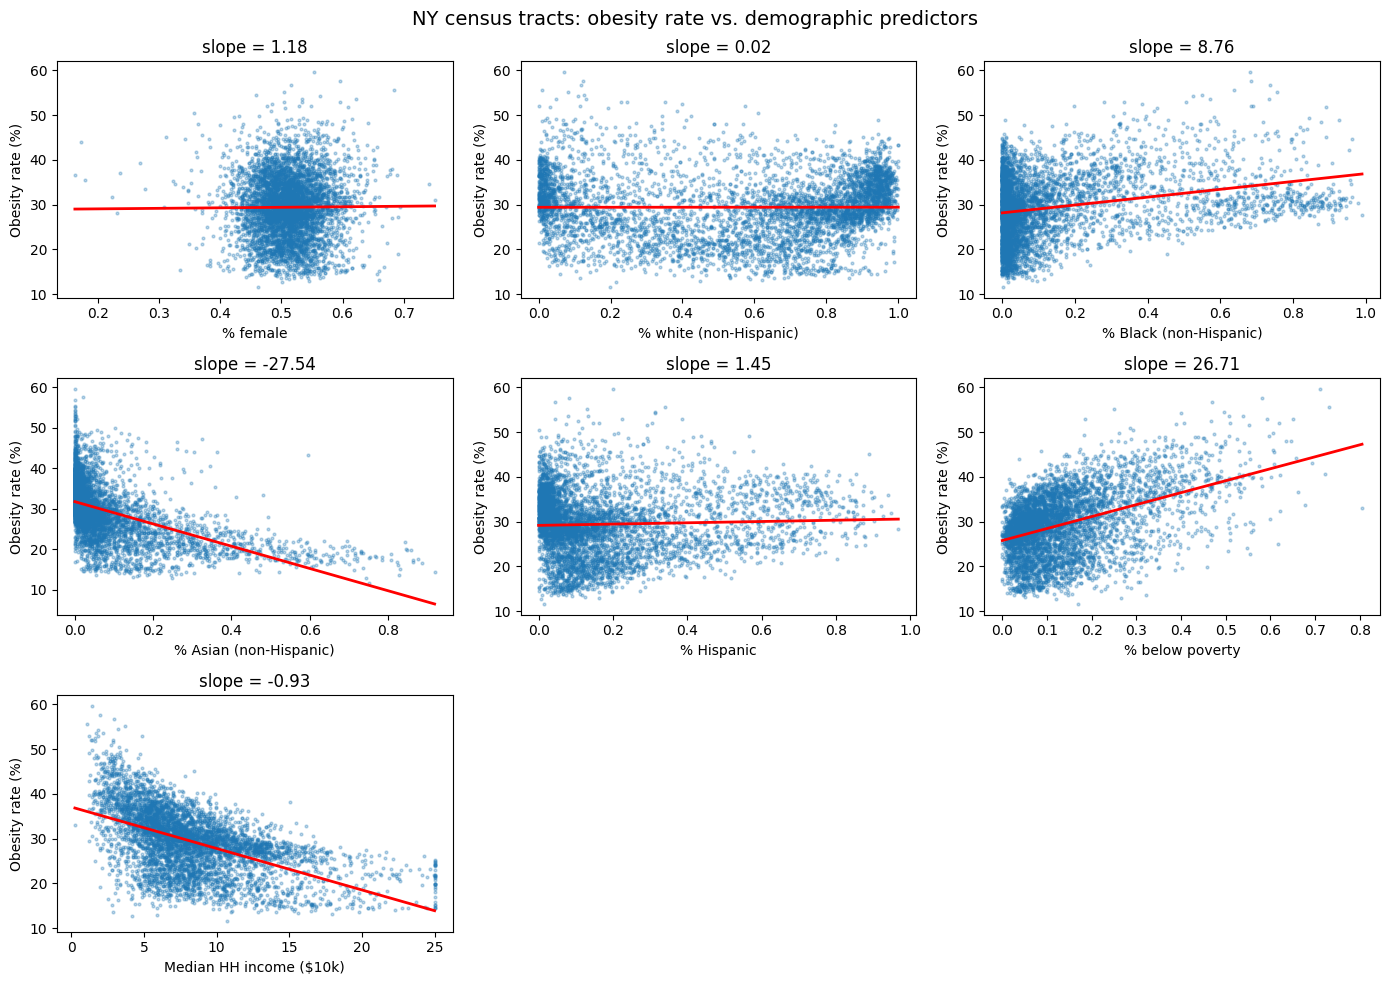

In [29]:
from matplotlib import rcParams
rcParams["figure.figsize"] = (14, 10)

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

plot_vars = [
    ("pct_female",   "% female"),
    ("pct_white",    "% white (non-Hispanic)"),
    ("pct_black",    "% Black (non-Hispanic)"),
    ("pct_asian",    "% Asian (non-Hispanic)"),
    ("pct_hispanic", "% Hispanic"),
    ("pct_poverty",  "% below poverty"),
    ("med_inc_10k",  "Median HH income ($10k)"),
]

for ax, (var, label) in zip(axes, plot_vars):
    ax.scatter(reg_df[var], reg_df["OBESITY_CrudePrev"], s=4, alpha=0.3)
    # simple OLS line: obesity ~ var
    b1, b0 = np.polyfit(reg_df[var], reg_df["OBESITY_CrudePrev"], 1)
    xs = np.linspace(reg_df[var].min(), reg_df[var].max(), 100)
    ax.plot(xs, b0 + b1 * xs, color="red", linewidth=2)
    ax.set_xlabel(label)
    ax.set_ylabel("Obesity rate (%)")
    ax.set_title(f"slope = {b1:.2f}")

for ax in axes[len(plot_vars):]:
    ax.axis("off")

fig.suptitle("NY census tracts: obesity rate vs. demographic predictors", fontsize=14)
fig.tight_layout()
plt.show()


### What is this and what stories can I tell?

Each dot is one NY census tract. The x-axis is a demographic share (or median income), the y-axis is the adult obesity rate for that tract, and the red line is a simple one-variable OLS fit. The slope in each title tells you how many **percentage points** the obesity rate moves when that predictor goes up by 1 unit (1 = 100% of the tract for shares, or $10,000 for income).

- **Poverty and obesity track together.** A positive slope on `% below poverty` is the classic public-health finding: poorer tracts tend to have higher adult obesity. If the dots fan out at low poverty and tighten at high poverty, that's heteroskedasticity — worth noting.
- **Income is the flip side.** `Median HH income ($10k)` should slope *down*. Comparing its slope to the poverty slope tells you whether absolute income or the poverty threshold is doing more work.
- **Race/ethnicity is not a cause — it's a signal of structural inequality.** Higher `% Black` or `% Hispanic` tracts often show higher obesity rates, but once you control for poverty in the multivariate regression (Step 6), those coefficients usually shrink. The story: race-linked disparities in obesity are largely mediated by income, food access, and neighborhood environment, not biology.
- **`% white` and `% Asian` typically slope negative** in NY tracts, again mostly reflecting that these tracts are on average wealthier.
- **Sex (`% female`) should be close to flat** — tracts don't vary much in sex composition, so this is mostly a sanity check.
- **Compare the bivariate slopes here to the multivariate coefficients in the Step 6 summary.** Big differences = confounding. For example, if `% Black` has a strong positive slope here but a near-zero coefficient once poverty is included, poverty was the real driver.
- **Outliers are a story too.** Tracts way above the red line (high obesity given their demographics) or way below it are worth looking up by `GEOID` — they may reflect food deserts, walkability, or institutional populations (prisons, college dorms) that the model doesn't see.

The single-variable lines here are descriptive only — for causal-sounding claims, lean on the multivariate regression output in Step 6, and remember this is an **ecological** analysis (tract-level), so conclusions apply to neighborhoods, not individuals.